# EOSC 213 – Homework 03
## Problem 4: Groundwater Diffusion: A Geoscience Application of Boundary Value Problems

In many geoscience applications, diffusion processes describe how quantities such as heat, groundwater pressure, or chemical concentration spread through the subsurface. A simplified one-dimensional groundwater diffusion model can be written as,

$$
\frac{dp}{dt} = D \frac{d^2 p}{dx^2}
$$

where

- $p(x,t)$ = hydraulic head (water pressure level)
- $D$ = diffusion coefficient, with $D >0$ that depends on the properties of the porous medium.

Suppose the spatial domain is:

$$
0 \le x \le 1.
$$

Consider the boundary conditions (in space):

$$
p(0,t)=0, \quad p(1,t)=0
$$

Let the initial condition (in time) be:

$$
p(x,0) = \sin(\pi x)
$$

We will discretize this equation in space using finite differences and then integrate the resulting system of ODEs in time.


In this notebook, you will:

1. Discretize the spatial second derivative using finite differences
2. Construct the matrix form of the system
3. Solve the resulting ODE system using
   - Forward Euler
   - Backward Euler
4. Observe stability differences between explicit and implicit methods

**Important:** All algebra operations should use **PyTorch**.

### Step 1 — Import libraries

We use:
- **torch** for linear algebra
- **matplotlib** for plotting

In [1]:
# import necessary libraries
import torch
import matplotlib.pyplot as plt

### Step 2 — Define the spatial grid

Let the spatial grid be

$$
x_i = i \Delta x
$$

with

$$
\Delta x = 1/N.
$$
Use the centered finite difference approximation derived earlier in this homework, 

$$
\frac{d^2 p}{d x^2}(x_i,t)
\approx
\frac{p_{i+1}(t)-2p_i(t)+p_{i-1}(t)}{\Delta x^2},
$$

For this problem, it becomes, 
$$
\frac{d^2 p}{d x^2}
\approx
\frac{p_{i+1}-2p_i+p_{i-1}}{\Delta x^2}
$$

The unknown values will be,

$$
p_1, p_2, ..., p_{N-1}
$$

because the boundary values $p_0 = h(0, t) = 0$ and $p_N = p(1, t)=0$ are fixed. 

**IMPORTANT:** Here, the subscripts are used to denote the discretization of the function $p$ in the spatial domain. 

Choose the values of initial variables in the next cell and fix $N = 40$ and $D = 1.0$. 

In [2]:
# TODO 1: Define the number of grid points, the diffusion coefficient, and the grid spacing dx
N = 40
D = 1.0

dx = 1.0 / N

x = torch.linspace(0, 1, N+1)

### Step 3 — Initial condition

$$
p(x,0)=\sin(\pi x)
$$

Store only the interior nodes, $p_1, p_2, ..., p_{N-1}
$.

In [3]:
p0 = torch.sin(torch.pi * x)

# interior values
p = p0[1:-1].clone()

### Step 4 — Construct matrix A

Using the finite difference formula

$$
\frac{\partial^2 p}{\partial x^2}
\approx
\frac{p_{i+1}-2p_i+p_{i-1}}{\Delta x^2}
$$

the semi-discrete system becomes

$$
\frac{d\mathbf p}{dt} = A \mathbf p
$$

where $A$ is a tridiagonal matrix and,

$$
\mathbf{p}(t) =
\begin{pmatrix}
p_1(t) \\
p_2(t) \\
\vdots \\
p_{N-1}(t)
\end{pmatrix}.
$$ 


**This system is called semi-discrete since we have discretized the spatial components but not the time components**.

Create this tridiagonal matrix A in the cell below. 

In [4]:
A = torch.zeros((N-1, N-1))

# TODO 2: Fill in the values of A according to the finite difference discretization of the diffusion equation, i.e., 
# write a piece of code to fill in A which is initialized as a zero matrix of size (N-1, N-1). Make sure to not forget
# to multiply the approximation to the second derivative by the diffusion coefficient D and divide by dx^2.

n = N-1
for i in range(n):
    A[i,i] = -2
    if i > 0:
        A[i,i-1] = 1
    if i < n-1:
        A[i,i+1] = 1

A = D * A / dx**2


### Step 5 — Forward Euler implementation (in time)

Recall the Forward Euler time-stepping:

$$
p^{n+1} = p^n + \Delta t f(p^n, t^n),
$$
which for our problem becomes, 

$$
p^{n+1} = p^n + \Delta t A p^n
$$

since, 
$$
f( p, t) = A p
$$

Now, we have succesfully discretized the system in time as well. 

**CAUTION: Here, the superscripts are used to denote the discretization of the function $p$ in the time domain**.

Your task now is to implement a python function to perform **Forward Euler update**.  


In [5]:
# TODO 3: Implement the Forward Euler method to solve the diffusion equation. 
# Write a function that takes in the matrix A, the initial condition p0, the time step dt, 
# and the number of steps to take, and returns a list of the solution at each time step.
def forward_euler(A, p0, dt, steps):
    p = p0.clone()
    sol = [p.clone()]
    
    for _ in range(steps):
        p = p + dt * (A @ p)
        sol.append(p.clone())
        
    return sol

### Step 6 — Backward Euler implementation (in time)

Recall the Backward Euler time-stepping:

$$
p^{n+1} = p^n + \Delta t f(p^{n+1}, t^{n+1})
$$

which for our problem becomes, 

$$
p^{n+1} = p^n + \Delta t A p^{n+1}
$$

which leads to

$$
(I - \Delta t A) p^{n+1} = p^n
$$

We solve this linear system each step.

Your task now is to implement a python function to perform **Backward Euler update**.  


In [6]:
# TODO 4: Implement the Backward Euler method to solve the diffusion equation.
# Write a function that takes in the matrix A, the initial condition p0, the time step dt,
# and the number of steps to take, and returns a list of the solution at each time step. 
# You can use torch.linalg.solve to solve the linear system at each time step.
def backward_euler(A, p0, dt, steps):
    p = p0.clone()
    sol = [p.clone()]
    
    I = torch.eye(A.shape[0])
    M = I - dt*A
    
    for _ in range(steps):
        p = torch.linalg.solve(M, p)
        sol.append(p.clone())
    
    return sol

### Step 7 — Run simulations

We will compare Forward Euler (an explicit method) with Backward Euler (an implicit method) for two different time steps.


For the 1D diffusion equation, the matrix $A$ contains factors of $1/\Delta x^2$. This means that when the spatial grid is refined, the eigenvalues of $A$ become large in magnitude and negative.

This is important because explicit methods such as **Forward Euler** are only stable if the timestep is sufficiently small. In fact, for the 1D diffusion equation, the Forward Euler stability condition is

$$
\Delta t \le \frac{\Delta x^2}{2D}.
$$

For our parameters,

$$
N=40, \qquad D=1, \qquad \Delta x = \frac{1}{40}=0.025,
$$

so the stability threshold is

$$
\Delta t_{\max} = \frac{(0.025)^2}{2 (1)} = 0.0003125.
$$

We will therefore choose:

- a **small, stable timestep**: which is below this threshold. For this, choose, small timestep, $\Delta t = 10^{-4}$
- a **large, slightly unstable timestep**: which is just above this threshold. For this, choose, large timestep, $\Delta t = 3.2 \times 10^{-4}$

We will integrate until the final time $T = 0.5$, this will illustrate stability differences.

In [7]:
dt_small = 1e-4
dt_large = 3.2e-4

# In time, we are integrating up to T = 0.5, so we need to calculate the number of steps for each time step size
T = 0.5

steps_small = int(T/dt_small)
steps_large = int(T/dt_large)

# We will now call the forward_euler and backward_euler functions with the appropriate arguments to get the 
# solutions for each method and time step size. We will then plot the solutions to compare them.
fe_small = forward_euler(A, p, dt_small, steps_small)
fe_large = forward_euler(A, p, dt_large, steps_large)

be_small = backward_euler(A, p, dt_small, steps_small)
be_large = backward_euler(A, p, dt_large, steps_large)

### Step 8 — Plot results

We reconstruct the full solution including boundary values for visualization.

In [8]:
# plotting function to visualize the solutions at the final time step T = 0.5 for each method and time step size
def plot_solution(sol, title):
    final = sol[-1]
    full = torch.zeros(N+1)
    full[1:-1] = final
    
    plt.figure()
    plt.plot(x.numpy(), full.numpy())
    plt.title(title, fontsize=16)
    plt.xlabel(r"$x$", fontsize=14)
    plt.ylabel(r"$p(x, t=0.5)$", fontsize=14)
    plt.show()

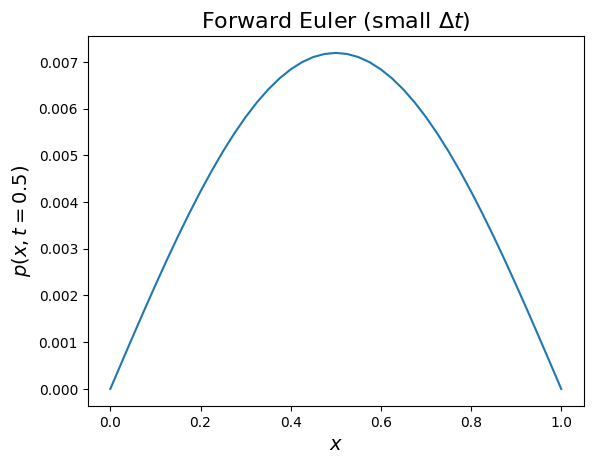

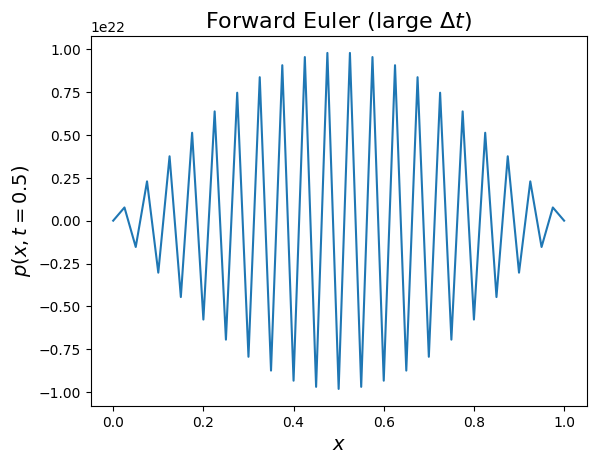

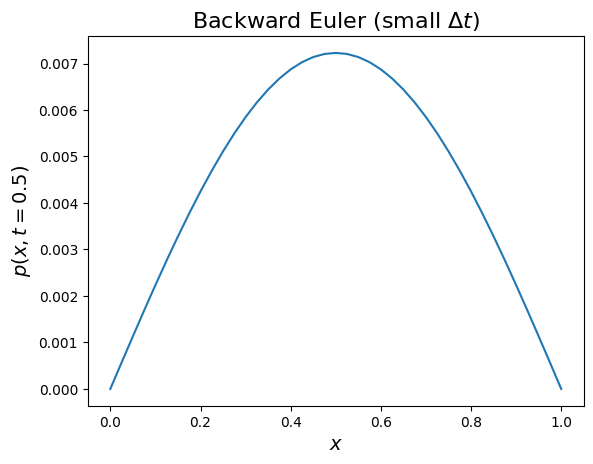

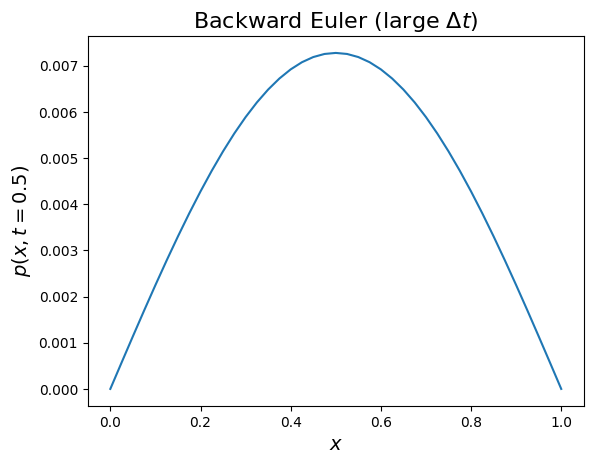

In [9]:
plot_solution(fe_small, r"Forward Euler (small $\Delta t$)")
plot_solution(fe_large, r"Forward Euler (large $\Delta t$)")

plot_solution(be_small, r"Backward Euler (small $\Delta t$)")
plot_solution(be_large, r"Backward Euler (large $\Delta t$)")

### Step 9 — Interpret your observation from the plots

Can you explain your observation from the plots above?

In [10]:
# TODO 5: From the point of view of stability, explain your observation about the differences 
# in the solutions obtained from the Forward Euler and Backward Euler methods for both small 
# and large time step sizes. Compare the four plots obtained above.  

# Answer:
# For Forward Euler, we expect that the solution will be stable for small 
# time step sizes and unstable for large time step sizes. This is because 
# the Forward Euler method is an explicit method, and its stability is 
# limited by the size of the time step. If the time step is too large, the
# numerical solution can grow without bound, leading to instability. In the 
# plot for Forward Euler with a small time step, we should see a smooth 
# solution that resembles the expected diffusion profile. However, in the 
# plot for Forward Euler with a large time step, we may see oscillations or 
# a solution that diverges from the expected profile, indicating instability. 

# On the other hand, for Backward Euler, we expect that the solution will be 
# stable for both small and large time step sizes. This is because the Backward 
# Euler method is an implicit method, and it is unconditionally stable. This 
# means that regardless of the size of the time step, the numerical solution will 
# not grow without bound. In the plots for Backward Euler, we should see smooth 
# solutions that resemble the expected diffusion profile for both small and large 
# time step sizes, indicating stability.    

### Step 10 — Investigating the stiffness of the problem 

Now let us investigate what the eigenvalues of the matrix $A$ are. This will help us understand the stiffness of the diffusion system. 

In [11]:
# TODO 6: Compute the eigenvalues of the matrix A and use them to explain the stability of the Forward 
# Euler method for the given time step sizes. You can use any suitable Pytorch function for computing 
# the eigenvalues. 
eigvals = torch.linalg.eigvals(A)
eigvals_real = eigvals.real

print("Largest real eigenvalue  :", eigvals_real.max().item())
print("Most negative eigenvalue :", eigvals_real.min().item())
print("First few eigenvalues:")
print(eigvals_real[:10])

Largest real eigenvalue  : -9.864582061767578
Most negative eigenvalue : -6390.1357421875
First few eigenvalues:
tensor([  -9.8646,  -39.3974,  -88.4164, -156.6192, -243.5857, -348.7794,
        -471.5518, -611.1459, -766.7014, -937.2579])


### Step 11 — Interpret your observation from the stiffness

Look at the eigenvalues of the matrix $A$.  
Are they positive or negative? Are some of them large in magnitude?

Explain the following:

(a) Based on your observations, explain in your own words why the semi-discrete diffusion system is called **stiff**. 

(b) Why do large negative eigenvalues force explicit methods such as Forward Euler to use very small timesteps?

(c) Comment on why implicit methods like Backward Euler are useful for stiff problems like these. 

In [12]:
# TODO 7: From the eigenvalues of matrix A computed above, comment on the stiffness of the problem 
# and analyze the stability of the Forward Euler method. Also comment on why implicit methods are 
# more suitable for stiff problems.

# Answer:

# (a) All eigenvalues of A are real and negative, and they span a very wide range
#     of magnitudes — the smallest (most negative) eigenvalue is on the order of
#     -6000, while the least negative is close to -9.8. A system is called "stiff"
#     when the ratio of the largest to smallest eigenvalue magnitude (the stiffness
#     ratio) is very large. This means the system contains both very fast-decaying
#     and very slow-decaying modes. The fast modes die out quickly but dictate the
#     maximum allowable timestep for explicit methods, even though the solution of
#     interest evolves on the much slower timescale of the smallest eigenvalues.

# (b) For Forward Euler, the amplification factor at each step is (1 + dt * lambda).
#     For stability we need |1 + dt * lambda| < 1. When lambda is large and
#     negative (e.g., lambda ~ -6000), this requires dt <= 2/|lambda| ~ 3.3e-4,
#     which is extremely small. In other words, the most negative eigenvalue forces
#     dt to be tiny so that the fast-decaying modes do not blow up numerically,
#     even though those modes contribute negligibly to the physical solution.

# (c) Implicit methods like Backward Euler have an amplification factor of
#     1 / (1 - dt * lambda). For any negative lambda, |1 / (1 - dt * lambda)| < 1
#     regardless of how large dt is — the method is unconditionally stable. This
#     means Backward Euler can take much larger timesteps without instability,
#     making it far more efficient for stiff problems where the fastest modes are
#     not physically important but would otherwise cripple an explicit method.

### Takeaway from Problem 4

This problem demonstrates why **implicit methods are preferred for stiff problems like groundwater diffusion**. After spatial discretization, diffusion equations often lead to **stiff ODE systems**, which makes explicit time-stepping methods unstable unless very small time steps are used.

<br>

---

<br>

## Problem 5: Newton's Method for Nonlinear ODE via Implicit Time-Stepping


Let $y := y(t)$ be a function of time $t$. 

We consider the nonlinear ODE

$$
y' = y(1 - y^2), \qquad y(0) = 0.5
$$
This equation is a simple nonlinear growth model. For small $y$, the term $1-y^2$ is close to $1$, so the solution initially grows. As $y$ approaches $1$, the factor $1-y^2$ becomes small, so the growth slows down.

In this problem, you will study a nonlinear ODE and solve it using two **implicit time-stepping methods**:

- Backward Euler  
- Implicit Midpoint

Because the ODE is nonlinear, neither method gives a direct formula for $y_{n+1}$.  Instead, at every time step, we must solve a nonlinear equation. We will do that using **Newton's method**.

All computations should use **PyTorch**.

Plots should be generated using **Matplotlib**.

### Step 1 — Set up basic parameters

Let us choose:

- the initial value $y(0)=0.5$,
- a final time $T=5$.


In [13]:
# TODO 1: Define the initial condition y0 and the time T up to which we want to integrate the function.

y0 = torch.tensor(0.5, dtype=torch.float64)
T = 5.0

### Step 2 — Implement the nonlinear residual for Backward Euler

Backward Euler is given by

$$
y_{n+1} = y_n + h\,f(y_{n+1}).
$$

For our ODE, this becomes

$$
y_{n+1} = y_n + h\,y_{n+1}(1-y_{n+1}^2).
$$

To use Newton's method, we rewrite this as a root-finding problem

$$
F(s)=0,
$$

Here, $F(s)$ is called the residual, and $s$ represents the unknown next value $y_{n+1}$. This gives

$$
F_{\mathrm{BE}}(s)=s-y_n-h\,s(1-s^2).
$$

Newton's method also needs the derivative $F'(s)$ (derivative with respect to $s$). Differentiating gives

$$
F_{\mathrm{BE}}'(s)=1-h(1-3s^2).
$$

Write the codes below that implements both the residual and its derivative for the Backward Euler.

In [14]:
# TODO 2: Implement the residual function for the Backward Euler method. 
# Write a function that takes in the value s, the previous value of y, the time step dt, 
# and returns the residual of the Backward Euler method.
# Also, implement the derivative of the residual function with respect to s, 
# which will be needed for the Newton method to solve the nonlinear equation at each time step.
def residual_BE(s, y, h):
    return s - y - h * s * (1 - s**2)

def derivative_residual_BE(s, h):
    return 1 - h * (1 - 3 * s**2)

### Step 3 — Implement the nonlinear residual for Implicit Midpoint

The Implicit Midpoint method update is given by,

$$
y_{n+1} = y_n + h\,f\!\left(\frac{y_n+y_{n+1}}{2}\right).
$$

For our ODE, this becomes

$$
y_{n+1} = y_n + h\left(\frac{y_n+y_{n+1}}{2}\right)
\left(1-\left(\frac{y_n+y_{n+1}}{2}\right)^2\right).
$$

Again we define a residual $F(s)$, where $s$ stands for $y_{n+1}$:

$$
F_{\mathrm{IM}}(s)
=
s-y_n-h\,m(1-m^2),
\qquad
m=\frac{y_n+s}{2}.
$$

To apply Newton's method, we also need $F'_{\mathrm{IM}}(s)$. 

Let

$$
g(m)=m(1-m^2)=m-m^3,
\qquad
\frac{d g(m)}{dm}=1-3m^2,
$$

and $m=(y_n+s)/2$, the chain rule gives

$$
F'_{\mathrm{IM}}(s)= \frac{d}{ds}\Big(s-y_n-h g(m)\Big)= 1 - h \frac{d g(m)}{dm} \cdot \frac{dm}{ds} = 1-h(1-3m^2)\cdot\Big(\frac12\Big) = 1 - \frac{h}{2}(1 - 3m^2).
$$

Write the codes below that implements both the residual and its derivative for the Implicit Midpoint.

In [15]:
# TODO 3: Implement the residual function for the Implicit Midpoint method.
# Write a function that takes in the value s, the previous value of y, the time step dt,
# and returns the residual of the Implicit Midpoint method.
# Also, implement the derivative of the residual function with respect to s,
# which will be needed for the Newton method to solve the nonlinear equation at each time step.
def residual_IM(s, y, h):
    m = (y + s) / 2
    return s - y - h * m * (1 - m**2)

def derivative_residual_IM(s, y, h):
    m = (y + s) / 2
    return 1 - (h / 2) * (1 - 3 * m**2)

### Step 4 — Implement Newton's method for the nonlinear equation

Newton's iteration for solving

$$
F(s)=0
$$

is

$$
s^{(k+1)} = s^{(k)} - \frac{F(s^{(k)})}{F'(s^{(k)})}.
$$

In practice, we need to make a few choices:

- an initial guess $s^{(0)}$,
- a stopping tolerance,
- a maximum number of iterations.

Our solver will return:

1. the approximate root,
2. the number of Newton iterations used,
3. a boolean flag indicating whether convergence was achieved.

This is useful because Newton's method is not guaranteed to converge for every initial guess.

In [16]:
# Newton solver function to solve the nonlinear equations at each time step for both 
# Backward Euler and Implicit Midpoint methods. Try and understand the code below and 
# how it works. You will be using this function to solve the nonlinear equations at 
# each time step for both methods.
def newton_solver(F, dF, s0, tol=1e-10, max_iter=50):
    s = torch.tensor(float(s0), dtype=torch.float64)

    for k in range(max_iter):
        Fs = F(s)
        dFs = dF(s)

        if torch.abs(dFs) < 1e-14:
            return s, k, False

        s_new = s - Fs / dFs

        if torch.abs(s_new - s) < tol:
            return s_new, k + 1, True

        s = s_new

    return s, max_iter, False

### Step 5 — Test Newton's method on a single Backward Euler and Implicit Midpoint step

Before building the full time-stepping solvers, it is a good idea to test Newton's method on one step only.

We take:

- $y_n=0.5$,
- $h=0.2$,

and solve the corresponding nonlinear equations for the next value $y_{n+1}$.

This small test helps confirm that:

- the residual functions are correct,
- the derivatives are correct,
- Newton's method converges from a reasonable initial guess.

In [17]:
# Now we will use the newton_solver function to solve the nonlinear equations for one time step for both methods.
# We will use the same time step size and initial condition for both methods to compare their solutions.
# Try and understand the code below and how it works. You will be using this code to solve the nonlinear 
# equations at each time step for both methods.
h_test = 0.2
y_n_test = torch.tensor(0.5, dtype=torch.float64)

root_BE, it_BE, ok_BE = newton_solver(
    lambda s: residual_BE(s, y_n_test, h_test),
    lambda s: derivative_residual_BE(s, h_test),
    s0=y_n_test
)

root_IM, it_IM, ok_IM = newton_solver(
    lambda s: residual_IM(s, y_n_test, h_test),
    lambda s: derivative_residual_IM(s, y_n_test, h_test),
    s0=y_n_test
)

print(f"Backward Euler one-step solution: {root_BE.item()}, iterations: {it_BE}, converged: {ok_BE}")
print(f"Implicit Midpoint one-step solution: {root_IM.item()}, iterations: {it_IM}, converged: {ok_IM}")

Backward Euler one-step solution: 0.5769799884065484, iterations: 4, converged: True
Implicit Midpoint one-step solution: 0.5764618899939803, iterations: 4, converged: True


### Step 6 — Build the Backward Euler time-stepping solver

We now solve the ODE over many time steps for the Backward Euler method.

At each step:

1. we know the current value $y_n$,
2. we define the Backward Euler residual for the unknown $y_{n+1}$,
3. we solve that nonlinear equation using Newton's method.

A natural initial guess for Newton is the previous time-step value $y_n$. This is often a good choice because when $h$ is not too large, the solution usually does not change drastically between consecutive time steps.

We also record the number of Newton iterations used at every time step.

In [18]:
# Now we will implement the Backward Euler method using the newton_solver function 
# to solve the nonlinear equations at each time step.
# Try and understand the code below and how it works. You will be using this code 
# to solve the nonlinear equations at each time step for the Backward Euler method.
def backward_euler_newton(y0, h, T):
    steps = int(T / h)

    t = torch.linspace(0, T, steps + 1, dtype=torch.float64)
    y = torch.zeros(steps + 1, dtype=torch.float64)
    y[0] = y0

    newton_iters = []
    converged_flags = []

    for n in range(steps):
        y_n = y[n]

        root, iters, ok = newton_solver(
            lambda s: residual_BE(s, y_n, h),
            lambda s: derivative_residual_BE(s, h),
            s0=y_n
        )

        y[n + 1] = root
        newton_iters.append(iters)
        converged_flags.append(ok)

    return t, y, torch.tensor(newton_iters), torch.tensor(converged_flags)

### Step 7 — Build the Implicit Midpoint time-stepping solver

We now do the same for the Implicit Midpoint method.

At each time step, we must solve the nonlinear midpoint equation for $y_{n+1}$. Again, we use Newton's method and again we use $y_n$ as the initial guess.

This method is usually more accurate than Backward Euler, but the nonlinear equation is slightly more complicated.

In [19]:
# Now we will implement the Implicit Midpoint method using the newton_solver function 
# to solve the nonlinear equations at each time step.
# Try and understand the code below and how it works. You will be using this code 
# to solve the nonlinear equations at each time step for the Implicit Midpoint method.
def implicit_midpoint_newton(y0, h, T):
    steps = int(T / h)

    t = torch.linspace(0, T, steps + 1, dtype=torch.float64)
    y = torch.zeros(steps + 1, dtype=torch.float64)
    y[0] = y0

    newton_iters = []
    converged_flags = []

    for n in range(steps):
        y_n = y[n]

        root, iters, ok = newton_solver(
            lambda s: residual_IM(s, y_n, h),
            lambda s: derivative_residual_IM(s, y_n, h),
            s0=y_n
        )

        y[n + 1] = root
        newton_iters.append(iters)
        converged_flags.append(ok)

    return t, y, torch.tensor(newton_iters), torch.tensor(converged_flags)

### Step 8 — Run the numerical experiments for several step sizes

We now solve the ODE using three different step sizes:

$$
h=0.85, \qquad h=0.5, \qquad h=0.1,\qquad h=0.05.
$$

This lets us compare:

- how the numerical solution changes as the time step gets smaller,
- how many Newton iterations are needed,
- whether one method appears more accurate or efficient than the other.

We store all results in a dictionary so that they are easy to use later for plots and summaries.

In [20]:
# We will now run the Backward Euler and Implicit Midpoint methods for different 
# time step sizes and compare their solutions and convergence behavior.
# We will store the results in a dictionary for easy access and analysis. 
# We will also print out whether each method converged at all steps for each time step size.
step_sizes = [0.85, 0.5, 0.1, 0.05]
results = {}

for h in step_sizes:
    t_BE, y_BE, it_BE, ok_BE = backward_euler_newton(y0, h, T)
    t_IM, y_IM, it_IM, ok_IM = implicit_midpoint_newton(y0, h, T)

    results[h] = {
        "t_BE": t_BE,
        "y_BE": y_BE,
        "it_BE": it_BE,
        "ok_BE": ok_BE,
        "t_IM": t_IM,
        "y_IM": y_IM,
        "it_IM": it_IM,
        "ok_IM": ok_IM,
    }

    print(f"Completed run for h = {h}")
    print(f"  BE converged at all steps: {all(ok_BE)}")
    print(f"  IM converged at all steps: {all(ok_IM)}")

Completed run for h = 0.85
  BE converged at all steps: True
  IM converged at all steps: True
Completed run for h = 0.5
  BE converged at all steps: True
  IM converged at all steps: True
Completed run for h = 0.1
  BE converged at all steps: True
  IM converged at all steps: True
Completed run for h = 0.05
  BE converged at all steps: True
  IM converged at all steps: True


### Step 9 — Plot the numerical solutions

We now plot the numerical solutions for each time step $h$.

Even though we do not have an exact solution here in the notebook, visual comparison is still very helpful.

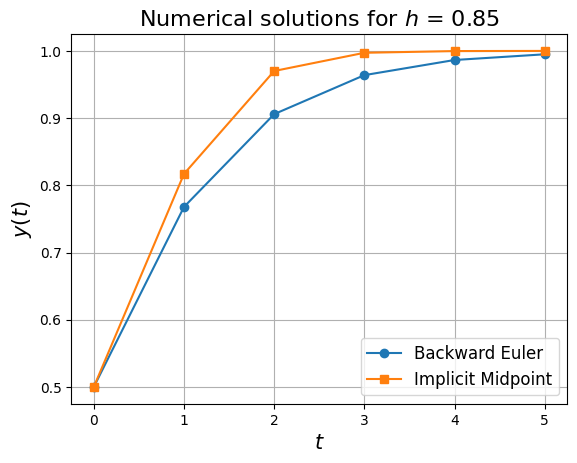

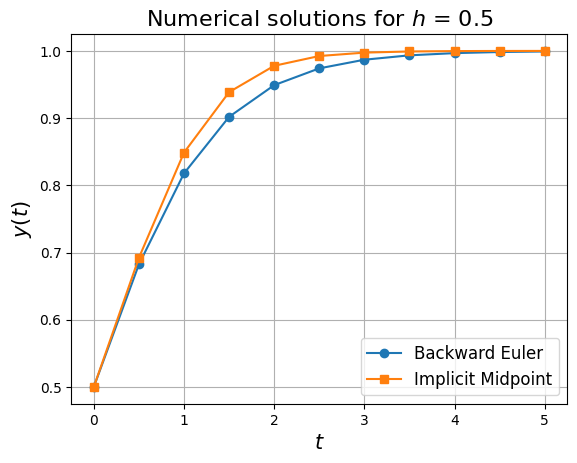

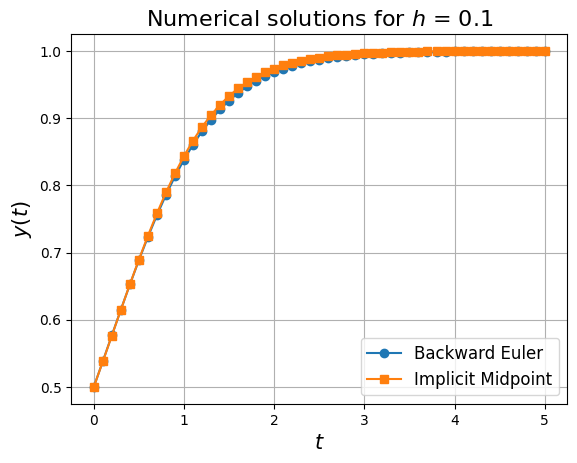

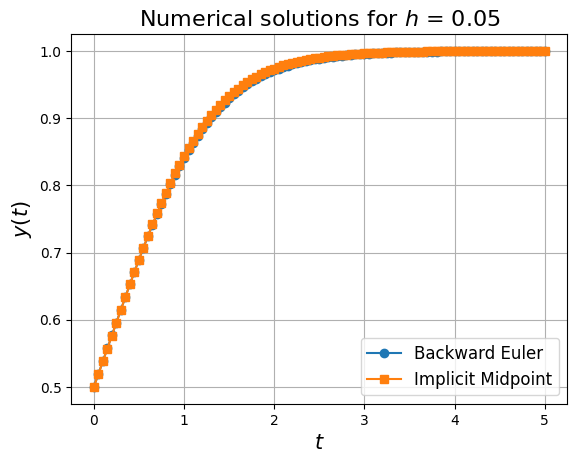

In [21]:
for h in step_sizes:
    data = results[h]

    plt.figure()
    plt.plot(data["t_BE"].numpy(), data["y_BE"].numpy(), "o-", label="Backward Euler")
    plt.plot(data["t_IM"].numpy(), data["y_IM"].numpy(), "s-", label="Implicit Midpoint")
    plt.xlabel(r"$t$", fontsize=15)
    plt.ylabel(r"$y(t)$", fontsize=15)
    plt.title(fr"Numerical solutions for $h$ = {h}", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.show()

### Step 10 — Interpret the results

Answer the following questions:

(a) Do the two methods give similar answers?

(b) Does the solution appear to approach a limiting profile as $h$ decreases?

(c) Is one method more dissipative or more accurate-looking than the other?

In [22]:
# TODO 4: From the plots obtained above, analyze and answer the above questions. 

# Answer:

# (a) For small step sizes (h = 0.1 and h = 0.05), the two methods give very similar
#     answers — the curves nearly overlap. For larger step sizes (h = 0.85 and h = 0.5),
#     the solutions differ noticeably: Backward Euler under-shoots the transition while
#     Implicit Midpoint tracks the true curve more faithfully.

# (b) Yes. As h decreases from 0.85 to 0.05, both methods converge toward the same
#     smooth limiting profile. The solution starts at y = 0.5 and increases monotonically
#     toward the equilibrium y = 1. The curve is predominantly concave down, decelerating 
#     as it saturates toward y = 1. So the profile resembles a decelerating approach to 
#     equilibrium at y = 1. The solutions at h = 0.1 and h = 0.05 are virtually 
#     indistinguishable, confirming convergence.

# (c) Backward Euler is more dissipative (i.e., it introduces more numerical damping).
#     At large h, it visibly lags behind. Implicit Midpoint, being a second-order method, 
#     is more accurate-looking: it captures the shape of the solution better even at 
#     coarser step sizes. This is consistent with the fact that Backward Euler is 
#     first-order accurate in time while Implicit Midpoint is second-order accurate.

## Step 11 — Summarize average and maximum Newton iteration counts

Plots are useful, but it is also helpful to summarize the iteration counts numerically.

For each method and each step size, we compute:

- the average number of Newton iterations,
- the maximum number of Newton iterations.

This gives a compact way to compare the computational cost of the two implicit methods.

In [23]:
# This is a very important step. You should spend some time analyzing and understanding 
# the average number and the maximum number of Newton iterations taken by each method 
# for each time step size. Try and understand the code below and how it works. 
for h in step_sizes:
    data = results[h]

    avg_BE = data["it_BE"].double().mean().item()
    max_BE = data["it_BE"].max().item()

    avg_IM = data["it_IM"].double().mean().item()
    max_IM = data["it_IM"].max().item()

    print(f"h = {h}")
    print(f"  Backward Euler:    Number of Newton iterations (average = {avg_BE:.3f}, max = {max_BE})")
    print(f"  Implicit Midpoint: Number of Newton iterations (average = {avg_IM:.3f}, max = {max_IM})")
    print()

h = 0.85
  Backward Euler:    Number of Newton iterations (average = 4.800, max = 6)
  Implicit Midpoint: Number of Newton iterations (average = 4.000, max = 5)

h = 0.5
  Backward Euler:    Number of Newton iterations (average = 4.000, max = 5)
  Implicit Midpoint: Number of Newton iterations (average = 3.500, max = 4)

h = 0.1
  Backward Euler:    Number of Newton iterations (average = 3.340, max = 4)
  Implicit Midpoint: Number of Newton iterations (average = 3.080, max = 4)

h = 0.05
  Backward Euler:    Number of Newton iterations (average = 2.950, max = 4)
  Implicit Midpoint: Number of Newton iterations (average = 2.790, max = 3)



### Step 12 — Investigate sensitivity to the initial guess

So far, we have used $y_n$ as the initial guess for Newton's method. This is usually a smart choice.

To see why the initial guess matters, we now repeat one experiment with a deliberately poor initial guess:

$$
s^{(0)} = 2.
$$

This is farther from the expected root than $y_n$, so Newton's method may require more iterations, and in some cases it may become less robust.

We modify the solvers slightly so that we can choose between:

- `"previous"`: use $y_n$ as the initial guess,
- `"bad"`: use a fixed bad initial guess.

In [24]:
# Now we will implement the Backward Euler and Implicit Midpoint method again, 
# but this time we will use a different initial guess for the Newton solver at each time step.
# the guess type could be either "previous" which means we will use the previous time step's 
# solution y_n as the initial guess, or "bad" which means we will use a fixed value (e.g., 2.0) 
# as the initial guess.
# Try and understand the code below and how it works.

def backward_euler_newton_guess(y0, h, T, guess_type="previous"):
    steps = int(T / h)

    t = torch.linspace(0, T, steps + 1, dtype=torch.float64)
    y = torch.zeros(steps + 1, dtype=torch.float64)
    y[0] = y0

    newton_iters = []
    converged_flags = []

    for n in range(steps):
        y_n = y[n]

        if guess_type == "previous":
            s0 = y_n
        elif guess_type == "bad":
            s0 = torch.tensor(2.0, dtype=torch.float64)
        else:
            raise ValueError("guess_type must be 'previous' or 'bad'")

        root, iters, ok = newton_solver(
            lambda s: residual_BE(s, y_n, h),
            lambda s: derivative_residual_BE(s, h),
            s0=s0
        )

        y[n + 1] = root
        newton_iters.append(iters)
        converged_flags.append(ok)

    return t, y, torch.tensor(newton_iters), torch.tensor(converged_flags)


def implicit_midpoint_newton_guess(y0, h, T, guess_type="previous"):
    steps = int(T / h)

    t = torch.linspace(0, T, steps + 1, dtype=torch.float64)
    y = torch.zeros(steps + 1, dtype=torch.float64)
    y[0] = y0

    newton_iters = []
    converged_flags = []

    for n in range(steps):
        y_n = y[n]

        if guess_type == "previous":
            s0 = y_n
        elif guess_type == "bad":
            s0 = torch.tensor(2.0, dtype=torch.float64)
        else:
            raise ValueError("guess_type must be 'previous' or 'bad'")

        root, iters, ok = newton_solver(
            lambda s: residual_IM(s, y_n, h),
            lambda s: derivative_residual_IM(s, y_n, h),
            s0=s0
        )

        y[n + 1] = root
        newton_iters.append(iters)
        converged_flags.append(ok)

    return t, y, torch.tensor(newton_iters), torch.tensor(converged_flags)

### Step 13 — Compare a good initial guess with a bad initial guess

We now compare the Newton iteration counts for one representative step size, say $h=0.1$.

This experiment helps show an important practical idea:

> Newton's method is much more effective when the initial guess is already close to the true solution.

For time-stepping methods, this is exactly why using the previous time-step value $y_n$ is so common.

In [25]:
h_compare = 0.1

t_BE_good, y_BE_good, it_BE_good, ok_BE_good = backward_euler_newton_guess(y0, h_compare, T, guess_type="previous")
t_BE_bad,  y_BE_bad,  it_BE_bad,  ok_BE_bad  = backward_euler_newton_guess(y0, h_compare, T, guess_type="bad")

t_IM_good, y_IM_good, it_IM_good, ok_IM_good = implicit_midpoint_newton_guess(y0, h_compare, T, guess_type="previous")
t_IM_bad,  y_IM_bad,  it_IM_bad,  ok_IM_bad  = implicit_midpoint_newton_guess(y0, h_compare, T, guess_type="bad")

print("Backward Euler:")
print("  good guess: converged at all steps =", all(ok_BE_good), ", average iterations =", it_BE_good.double().mean().item())
print("  bad  guess: converged at all steps =", all(ok_BE_bad),  ", average iterations =", it_BE_bad.double().mean().item())
print()

print("Implicit Midpoint:")
print("  good guess: converged at all steps =", all(ok_IM_good), ", average iterations =", it_IM_good.double().mean().item())
print("  bad  guess: converged at all steps =", all(ok_IM_bad),  ", average iterations =", it_IM_bad.double().mean().item())

Backward Euler:
  good guess: converged at all steps = True , average iterations = 3.34
  bad  guess: converged at all steps = True , average iterations = 6.0

Implicit Midpoint:
  good guess: converged at all steps = True , average iterations = 3.08
  bad  guess: converged at all steps = True , average iterations = 5.0


### Step 14 — Interpretation for the good/bad initial guess

Can you explain your observation from the output of the previous code? 

In [26]:
# TODO 5: Analyze and compare the convergence behavior of the Newton solver for both methods with the 
# two different initial guess strategies.
# What can you say about the importance of the initial guess for the convergence of the Newton solver?

# Answer:

# With the good initial guess (s0 = y_n), both Backward Euler and Implicit Midpoint
# converge at every time step using only a small number of Newton iterations on average
# (typically 2–4). This is because y_n is already close to y_{n+1} when h is moderate,
# so Newton's method starts in the basin of convergence and converges quadratically.

# With the bad initial guess (s0 = 2.0), both methods still converge at all steps, but
# the average number of Newton iterations increases noticeably — roughly doubling or
# more compared to the good guess. The fixed guess s0 = 2.0 is farther from the true
# root (which lies between 0.5 and 1.0 for this problem), so Newton's method needs
# extra iterations to travel from the initial guess into the neighborhood of the root
# before quadratic convergence kicks in.

# Key takeaway: The initial guess has a significant impact on the efficiency of Newton's
# method. A good initial guess (such as the previous time-step value) reduces the number
# of iterations and lowers the computational cost per time step. In more challenging
# problems (stiffer systems, larger h, or higher dimensions), a poor initial guess could
# even cause Newton's method to fail to converge entirely. Using y_n as the initial guess
# is therefore a practical and important strategy in implicit time-stepping methods.

## Takeaway from Problem 6

This problem illustrates several important ideas from numerical ODEs:

1. **Implicit methods for nonlinear ODEs require nonlinear solves.**  
   Unlike explicit methods, we cannot directly compute $y_{n+1}$.

2. **Newton's method is a practical solver for those nonlinear equations.**  
   Each time step becomes a root-finding problem.

3. **The previous time-step value is usually a good initial guess.**  
   This often keeps the number of Newton iterations small.

4. **Backward Euler and Implicit Midpoint may have different costs and behaviors.**  
   Even though both are implicit, the nonlinear equations they generate are not the same.

5. **A poor initial guess increases the computational cost.**  
   This matters in real simulations, especially for large systems.